In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


# 1. Generate the data

In [6]:
SEED = 1234
NUM_SAMPLES = 50

In [7]:
np.random.seed(SEED)

In [8]:
def generate_data(num_samples):
    """ Generate DUMMY data for linear regression. """
    weight = 3.5
    X = np.array(range(num_samples))
    random_noise = np.random.uniform(-10, 20, size=num_samples)
    y = weight * X + random_noise
    return X, y

In [11]:
# Generate random data
X, y = generate_data(num_samples=NUM_SAMPLES)
data = np.array([X, y]).T
print(f"Data Sample: \n{data[:5]}")

Data Sample: 
[[ 0.         13.01349885]
 [ 1.         14.74346086]
 [ 2.         20.90601551]
 [ 3.         17.23282485]
 [ 4.         32.97509596]]


In [12]:
# Load into a Pandas DataFrame
df = pd.DataFrame(data, columns=["X", "y"])
df.head()

,X,y
0,0.0,13.013499
1,1.0,14.743461
2,2.0,20.906016
3,3.0,17.232825
4,4.0,32.975096


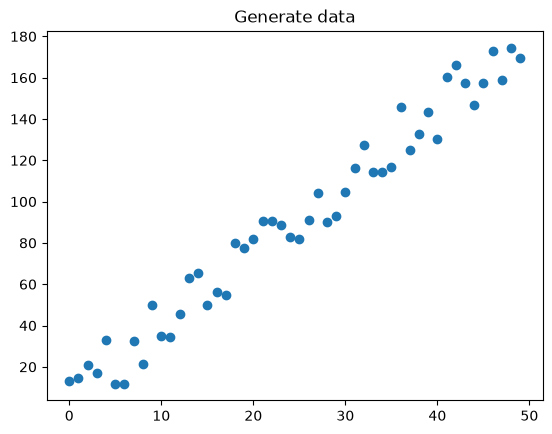

In [13]:
# Scatter plot
plt.title("Generate data")
plt.scatter(x=df["X"], y=df["y"])
plt.show();

# 2. Split data 

The data should be split into `train_set` and `test_set`.

In [21]:
TRAIN_SIZE = 0.7
VAL_SIZE = 0.15
TEST_SIZE = 0.15

In [23]:
# Shuffle data
indices = list(range(NUM_SAMPLES))
np.random.shuffle(indices)
X = X[indices]
y = y[indices]
# print(indices)
print(f"X shape: {X.shape} | y shape: {y.shape}")

X shape: (50,) | y shape: (50,)


In [27]:
# Split indices
train_start = 0
train_end = int(TRAIN_SIZE * NUM_SAMPLES)
val_start = train_end
val_end = int((TRAIN_SIZE + VAL_SIZE) * NUM_SAMPLES)
test_start = val_end

In [29]:
X_train = X[train_start:train_end]
y_train = y[train_start:train_end]
X_val = X[val_start:val_end]
y_val = y[val_start:val_end]
X_test = X[test_start:]
y_test = y[test_start:]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (35,), y_train: (35,)
X_val: (7,), y_val: (7,)
X_test: (8,), y_test: (8,)


# 3. Standardize data

We need to standardize our data (zero mean and unit variance) so a specific feature magnitude doesn't effect how the model learns its weights

In [42]:
def standardize_data(data, mean, std):
    return (mean - data) / std

In [43]:
X_mean = np.mean(X_train)
X_std = np.std(X_train)
y_mean = np.mean(y_train)
y_std = np.std(y_train)

In [44]:
X_train = standardize_data(X_train, X_mean, X_std)
y_train = standardize_data(y_train, y_mean, y_std)
X_val = standardize_data(X_val, X_mean, X_std)
y_val = standardize_data(y_val, y_mean, y_std)
X_test = standardize_data(X_test, X_mean, X_std)
y_test = standardize_data(y_test, y_mean, y_std)

In [45]:
X_test.shape

(8,)

In [46]:
print (f"mean: {np.mean(X_test):.1f}, std: {np.std(X_test):.1f}")
print (f"mean: {np.mean(y_test):.1f}, std: {np.std(y_test):.1f}")

mean: 0.1, std: 1.0
mean: 0.0, std: 1.3
